# Analyzing Reaction Rules

This tutorial shows how to inspect and analyze reaction rules extracted by SynPlanner. You will learn to:

- Load and browse rules with inline structure depictions
- Examine rule popularity distribution (Pareto analysis)
- Analyze product counts, element composition, and reaction center complexity
- Detect ring transformations, multi-center rules, and duplicates
- Compare two rule sets extracted under different configurations

**Prerequisites:** A TSV file of extracted rules (see Tutorial 03: Rules Extraction).

In [1]:
from pathlib import Path

from synplan.chem.reaction_rules.analysis import RuleSet
from synplan.chem.utils import cgr_from_reaction_rule, reaction_query_to_reaction

# Replace with your own rule file path
rules_path = Path("synplan_data/policy/supervised_gcn/v1/reaction_rules.tsv").resolve(True)

ruleset = RuleSet.from_tsv(rules_path)
ruleset[:10]  # preview first 10 rules with SVG depictions

Loading rules: 0it [00:00, ?it/s]

## 1. Popularity Overview

Reaction rules follow a long-tail distribution: a small fraction of rules covers most reactions. Understanding this distribution helps decide the `min_popularity` threshold for extraction and the number of rules needed for planning.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pop = np.array(ruleset.popularity)

print(f"Total rules: {len(pop)}")
print(f"Median popularity: {np.median(pop):.0f}")
print(f"90th percentile: {np.percentile(pop, 90):.0f}")
print(f"99th percentile: {np.percentile(pop, 99):.0f}")
print(f"Max popularity: {pop.max()}")

Total rules: 24094
Median popularity: 6
90th percentile: 42
99th percentile: 484
Max popularity: 23161


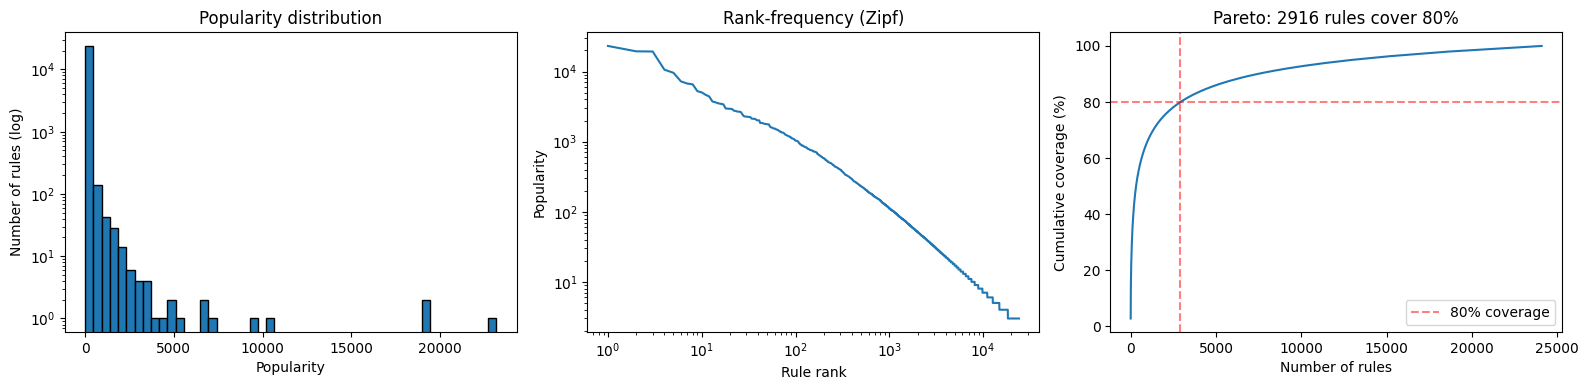

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Histogram (log scale)
axes[0].hist(pop, bins=50, edgecolor="black", log=True)
axes[0].set_xlabel("Popularity")
axes[0].set_ylabel("Number of rules (log)")
axes[0].set_title("Popularity distribution")

# Rank-frequency (log-log)
sorted_pop = np.sort(pop)[::-1]
axes[1].plot(range(1, len(sorted_pop) + 1), sorted_pop)
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_xlabel("Rule rank")
axes[1].set_ylabel("Popularity")
axes[1].set_title("Rank-frequency (Zipf)")

# Cumulative coverage
cumulative = np.cumsum(sorted_pop) / sorted_pop.sum() * 100
axes[2].plot(range(1, len(cumulative) + 1), cumulative)
axes[2].axhline(80, color="red", linestyle="--", alpha=0.5, label="80% coverage")
n_80 = np.searchsorted(cumulative, 80) + 1
axes[2].axvline(n_80, color="red", linestyle="--", alpha=0.5)
axes[2].set_xlabel("Number of rules")
axes[2].set_ylabel("Cumulative coverage (%)")
axes[2].set_title(f"Pareto: {n_80} rules cover 80%")
axes[2].legend()

plt.tight_layout()
plt.show()

## 2. Product Count Distribution

Each rule has a fixed number of products (retrosynthetic precursors). Most rules produce 1-2 products. Rules with many products are worth inspecting — they may represent complex multi-component reactions.

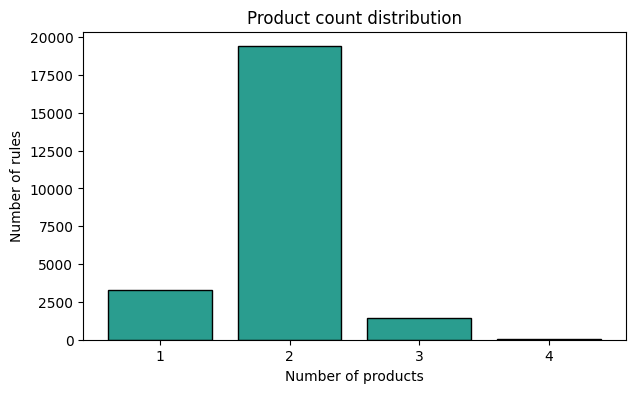

Distribution: {1: 3277, 2: 19384, 3: 1413, 4: 20}


In [4]:
from collections import Counter

n_products = [len(rule.products) for rule in ruleset]
dist = Counter(n_products)

plt.figure(figsize=(7, 4))
plt.bar(dist.keys(), dist.values(), color="#2a9d8f", edgecolor="black")
plt.xlabel("Number of products")
plt.ylabel("Number of rules")
plt.title("Product count distribution")
plt.xticks(sorted(dist.keys()))
plt.show()

print(f"Distribution: {dict(sorted(dist.items()))}")

In [5]:
# Inspect rules with the most products
k = max(n_products)
indices_k = [i for i, rule in enumerate(ruleset.rules) if len(rule.products) == k]
print(f"{len(indices_k)} rules with {k} products:")
ruleset[indices_k[:5]]

20 rules with 4 products:


## 3. Element Composition

Rules may contain atoms beyond the common organic set (C, N, O, H). Identifying rules with exotic elements (metals, metalloids) helps understand rule coverage and potential issues with building block availability.

1010 / 24094 rules contain special atoms (4.2%)


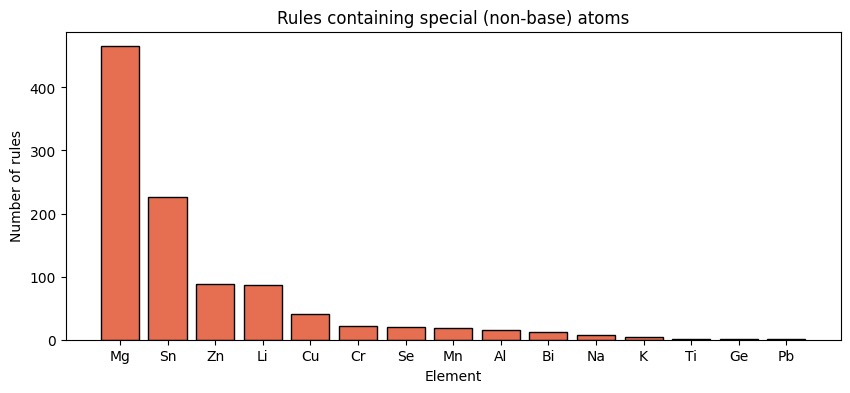

In [6]:
from collections import Counter

from synplan.chem.utils import query_to_mol

BASE_ATOMS = {"C", "N", "O", "H", "S", "Br", "Cl", "B", "I", "F", "P", "Si"}

element_counts = Counter()
rules_with_special = []

for i, rule in enumerate(ruleset):
    elements = set()
    for mol in (*rule.reactants, *rule.products):
        m = query_to_mol(mol)
        for _, atom in m.atoms():
            elements.add(atom.atomic_symbol)
    special = elements - BASE_ATOMS
    if special:
        rules_with_special.append((i, rule, special))
        element_counts.update(special)

print(f"{len(rules_with_special)} / {len(ruleset)} rules contain special atoms "
      f"({len(rules_with_special)*100/len(ruleset):.1f}%)")

if element_counts:
    elems, counts = zip(*element_counts.most_common())
    plt.figure(figsize=(10, 4))
    plt.bar(elems, counts, color="#e76f51", edgecolor="black")
    plt.xlabel("Element")
    plt.ylabel("Number of rules")
    plt.title("Rules containing special (non-base) atoms")
    plt.show()

In [7]:
# Inspect first 10 rules with special atoms
special_indices = [idx for idx, _, _ in rules_with_special[:10]]
print(f"Showing {len(special_indices)} rules with special atoms:")
ruleset[special_indices]

Showing 10 rules with special atoms:


## 4. Reaction Center Size

The reaction center consists of atoms and bonds that actually change during the reaction. Larger centers mean more specific rules. We extract this information from the Condensed Graph of Reaction (CGR).

Analyzing centers:   0%|          | 0/24094 [00:00<?, ?it/s]

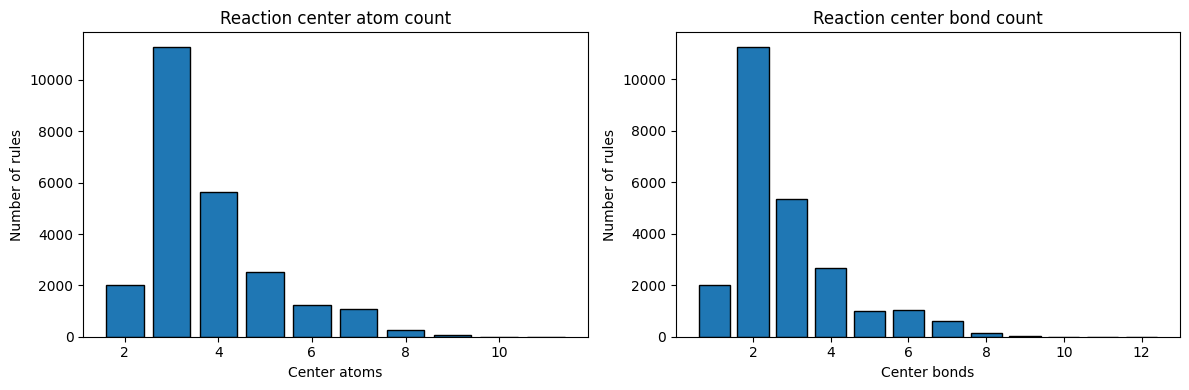

In [8]:
from tqdm.auto import tqdm

center_atoms_list = []
center_bonds_list = []
failed = []

for i, rule in enumerate(tqdm(ruleset, desc="Analyzing centers")):
    try:
        cgr = cgr_from_reaction_rule(rule)
        center_atoms_list.append(len(cgr.center_atoms))
        center_bonds_list.append(len(cgr.center_bonds))
    except Exception:
        failed.append(i)
        center_atoms_list.append(0)
        center_bonds_list.append(0)

if failed:
    print(f"Warning: {len(failed)} rules failed CGR conversion")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

atoms_dist = Counter(center_atoms_list)
axes[0].bar(atoms_dist.keys(), atoms_dist.values(), edgecolor="black")
axes[0].set_xlabel("Center atoms")
axes[0].set_ylabel("Number of rules")
axes[0].set_title("Reaction center atom count")

bonds_dist = Counter(center_bonds_list)
axes[1].bar(bonds_dist.keys(), bonds_dist.values(), edgecolor="black")
axes[1].set_xlabel("Center bonds")
axes[1].set_ylabel("Number of rules")
axes[1].set_title("Reaction center bond count")

plt.tight_layout()
plt.show()

## 5. Ring & Aromatic Transformations

Rules can create or open rings, change ring sizes, and alter aromaticity. This section analyzes how often these transformations occur across the rule set.

Analyzing rings:   0%|          | 0/24094 [00:00<?, ?it/s]

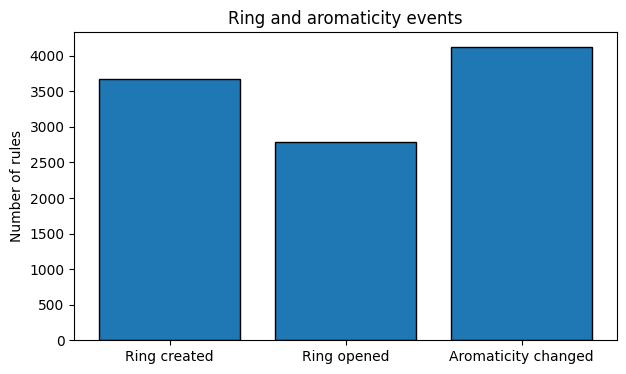

Ring created: 3677 (15.3%)
Ring opened: 2787 (11.6%)
Aromaticity changed: 4122 (17.1%)


In [9]:
from tqdm.auto import tqdm

def ring_bond_set(molecules):
    """Return set of (min, max) atom-pair tuples for all SSSR ring bonds."""
    bonds = set()
    for mol in molecules:
        for ring in mol.sssr:
            ring = list(ring)
            for a, b in zip(ring, ring[1:] + [ring[0]]):
                bonds.add((min(a, b), max(a, b)))
    return bonds

def aromatic_bond_set(molecules):
    """Return set of (min, max) atom-pair tuples for aromatic bonds."""
    bonds = set()
    for mol in molecules:
        for i, j, bond in mol.bonds():
            if int(bond) == 4:
                bonds.add((min(i, j), max(i, j)))
    return bonds

ring_created_list = []
ring_opened_list = []
arom_changed_list = []

for i, rule in enumerate(tqdm(ruleset, desc="Analyzing rings")):
    try:
        rxn = reaction_query_to_reaction(rule)
        r_rings = ring_bond_set(rxn.reactants)
        p_rings = ring_bond_set(rxn.products)
        ring_created_list.append(bool(p_rings - r_rings))
        ring_opened_list.append(bool(r_rings - p_rings))

        r_arom = aromatic_bond_set(rxn.reactants)
        p_arom = aromatic_bond_set(rxn.products)
        arom_changed_list.append(r_arom != p_arom)
    except Exception:
        ring_created_list.append(False)
        ring_opened_list.append(False)
        arom_changed_list.append(False)

events = {
    "Ring created": sum(ring_created_list),
    "Ring opened": sum(ring_opened_list),
    "Aromaticity changed": sum(arom_changed_list),
}

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(events.keys(), events.values(), edgecolor="black")
ax.set_ylabel("Number of rules")
ax.set_title("Ring and aromaticity events")
plt.show()

for name, count in events.items():
    print(f"{name}: {count} ({count*100/len(ruleset):.1f}%)")

In [10]:
creator_indices = [i for i, created in enumerate(ring_created_list) if created]
print(f"{len(creator_indices)} ring-creating rules. First 5:")
ruleset[creator_indices[:5]]

3677 ring-creating rules. First 5:


## 6. Multi-Center Rules

Some rules have disconnected reaction centers — multiple independent transformations happening in the same rule. These are often multi-component reactions (e.g., double acylation).

Detecting multi-centers:   0%|          | 0/24094 [00:00<?, ?it/s]

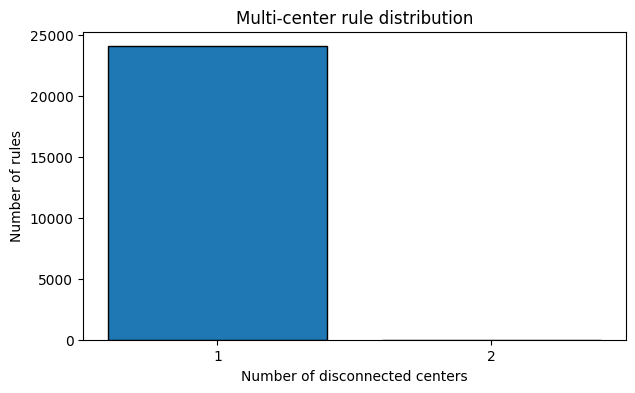

9 multi-center rules (0.0%)


In [11]:
from tqdm.auto import tqdm

multi_center_data = []

for i, rule in enumerate(tqdm(ruleset, desc="Detecting multi-centers")):
    try:
        cgr = cgr_from_reaction_rule(rule)
        centers = cgr.centers_list
        n_centers = len(centers)
    except Exception:
        n_centers = 0
    multi_center_data.append(n_centers)

center_dist = Counter(multi_center_data)
n_multi = sum(1 for nc in multi_center_data if nc > 1)

plt.figure(figsize=(7, 4))
plt.bar(center_dist.keys(), center_dist.values(), edgecolor="black")
plt.xlabel("Number of disconnected centers")
plt.ylabel("Number of rules")
plt.title("Multi-center rule distribution")
plt.xticks(sorted(center_dist.keys()))
plt.show()

print(f"{n_multi} multi-center rules ({n_multi*100/len(ruleset):.1f}%)")

In [12]:
multi_indices = [i for i, nc in enumerate(multi_center_data) if nc > 1]
print(f"First 5 multi-center rules:")
ruleset[multi_indices[:5]]

First 5 multi-center rules:


## 7. Duplicate Detection

Rules extracted from different reactions can be chemically equivalent even if their SMARTS strings differ. We detect duplicates using two methods:

1. **Canonical SMARTS**: exact string identity after re-serialization
2. **Canonical CGR**: chemical equivalence via the Condensed Graph of Reaction

In [13]:
from collections import defaultdict
from tqdm.auto import tqdm

# Method 1: by SMARTS string
smarts_groups = defaultdict(list)
for i, s in enumerate(ruleset.smarts_strings):
    smarts_groups[s].append(i)

smarts_dupes = {k: v for k, v in smarts_groups.items() if len(v) > 1}

# Method 2: by CGR hash
cgr_groups = defaultdict(list)
for i, rule in enumerate(tqdm(ruleset, desc="Computing CGR hashes")):
    try:
        cgr = cgr_from_reaction_rule(rule)
        cgr_groups[hash(cgr)].append(i)
    except Exception:
        pass  # unique by default if CGR fails

cgr_dupes = {k: v for k, v in cgr_groups.items() if len(v) > 1}

n_unique_smarts = len(smarts_groups)
n_unique_cgr = len(cgr_groups)

print(f"By SMARTS: {n_unique_smarts} unique / {len(ruleset)} total "
      f"({len(smarts_dupes)} duplicate groups)")
print(f"By CGR:    {n_unique_cgr} unique / {len(ruleset)} total "
      f"({len(cgr_dupes)} duplicate groups)")

Computing CGR hashes:   0%|          | 0/24094 [00:00<?, ?it/s]

By SMARTS: 23493 unique / 24094 total (540 duplicate groups)
By CGR:    10761 unique / 24094 total (3819 duplicate groups)


In [14]:
if cgr_dupes:
    top_dupes = sorted(cgr_dupes.values(), key=len, reverse=True)[:5]
    for group in top_dupes:
        print(f"Duplicate group ({len(group)} rules): indices {group}")
    # Show one representative rule from each duplicate group
    rep_indices = [sorted(cgr_dupes.values(), key=len, reverse=True)[i][0] for i in range(min(5, len(cgr_dupes)))]
    ruleset[rep_indices]

Duplicate group (129 rules): indices [20, 74, 141, 204, 273, 286, 310, 349, 350, 420, 483, 499, 582, 602, 611, 625, 648, 652, 669, 701, 719, 876, 889, 1024, 1120, 1153, 1159, 1268, 1329, 1415, 1431, 1441, 1540, 1632, 1709, 1739, 1760, 1771, 1825, 1876, 1972, 2023, 2041, 2054, 2075, 2177, 2489, 2636, 2641, 2678, 2695, 2760, 2830, 3213, 3336, 3449, 3772, 3835, 3923, 4015, 4070, 4088, 4095, 4101, 4276, 4541, 4554, 4621, 4672, 4883, 4890, 5088, 5583, 5841, 5896, 5967, 6224, 7025, 7195, 7279, 7296, 7559, 8124, 8228, 8236, 8244, 8450, 8536, 8961, 9022, 9067, 9171, 9696, 9895, 10141, 10399, 11341, 11708, 11852, 11907, 12583, 12782, 13060, 13544, 13683, 13839, 14475, 15039, 15187, 15859, 16600, 17495, 17909, 18454, 19369, 19370, 19678, 20197, 20820, 21082, 21244, 21250, 21357, 21598, 22055, 22165, 22718, 23041, 23646]
Duplicate group (107 rules): indices [60, 179, 216, 268, 340, 453, 475, 739, 790, 910, 981, 1014, 1030, 1083, 1144, 1149, 1277, 1304, 1335, 1354, 1373, 1413, 1501, 1564, 1693, 17

## 8. Comparing Two Rule Sets

When tuning extraction parameters, it is useful to compare rule sets extracted under different configurations. This section finds rules unique to each set.

In [ ]:
# Uncomment and set path to compare two rule sets:
# ruleset_b = RuleSet.from_tsv("path/to/other_rules.tsv")

# Example comparison (skip if only one rule set):
# cgr_set_a = set()
# for rule in tqdm(ruleset, desc="CGR set A"):
#     try:
#         cgr_set_a.add(cgr_from_reaction_rule(rule))
#     except Exception:
#         pass
#
# cgr_set_b = set()
# for rule in tqdm(ruleset_b, desc="CGR set B"):
#     try:
#         cgr_set_b.add(cgr_from_reaction_rule(rule))
#     except Exception:
#         pass
#
# only_a = cgr_set_a - cgr_set_b
# only_b = cgr_set_b - cgr_set_a
#
# print(f"Unique to A: {len(only_a)}")
# print(f"Unique to B: {len(only_b)}")
# print(f"Shared: {len(cgr_set_a & cgr_set_b)}")
#
# for cgr in list(only_a)[:5]:
#     cgr.clean2d()
#     display(cgr)

print("Uncomment cells above and set ruleset_b path to compare two rule sets.")